<a href="https://colab.research.google.com/github/forgetallyourworries/Pedjuang-Kompis-IDSC/blob/main/IDSC_DAFFA_HYGD_PTFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalasi library yang dibutuhkan
!pip install timm
!pip install scikit-learn
!pip install seaborn
!pip install opencv-python

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import cv2
import math
from tqdm import tqdm

In [ ]:
# ======================================================
# 1. KONFIGURASI GLOBAL (Ganti path sesuai lokasi Google Drive-mu)
# ======================================================
# --- GANTI BAGIAN INI JIKA PERLU ---
BASE_PATH = '/content/drive/MyDrive/Competition/IDSC 2026/Dataset/hillel-yaffe-glaucoma-dataset/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0'
IMAGE_DIR = os.path.join(BASE_PATH, 'Images')
CSV_PATH = os.path.join(BASE_PATH, 'Labels.csv')
# -----------------------------------

# Set seed global untuk reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Menggunakan device: {device}")

# ======================================================
# 2. TAHAP 1: PREPARATION & SPLIT (Patient-Level)
# ======================================================
def prepare_and_split(csv_path):
    print("\n--- Membaca Metadata & Deteksi Kolom ---")
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    cols = df.columns.str.lower()
    col_img = df.columns[['image' in c or 'file' in c or 'name' in c for c in cols]][0]
    col_pat = df.columns[['patient' in c or 'id' in c for c in cols]][0]
    col_lab = df.columns[['diagnosis' in c or 'label' in c or 'gon' in c for c in cols]][0]
    col_qty = df.columns[['quality' in c or 'score' in c for c in cols]][0]

    # Split: 73% Train, 13.5% Val, 13.5% Test
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.135, random_state=42)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df[col_pat]))
    df_train_val = df.iloc[train_val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.156, random_state=42)
    train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val[col_pat]))
    df_train = df_train_val.iloc[train_idx].copy()
    df_val = df_train_val.iloc[val_idx].copy()

    col_dict = {'img': col_img, 'pat': col_pat, 'lab': col_lab, 'qty': col_qty}
    print(f"✅ Data Terbagi! Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
    return df_train, df_val, df_test, col_dict

df_train, df_val, df_test, cols = prepare_and_split(CSV_PATH)

✅ Menggunakan device: cpu

--- Membaca Metadata & Deteksi Kolom ---
✅ Data Terbagi! Train: 558, Val: 97, Test: 92


In [ ]:
# ======================================================
# 3. TAHAP 2: PIPELINE AUGMENTASI (ANTI-LEAKAGE)
# ======================================================
IMG_SIZE = 224

# Standar untuk Val & Test (TIDAK ADA AUGMENTASI, HANYA RESIZE)
val_test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Augmentasi Menengah-Agresif UNTUK SEMUA KELAS (GON+ & GON-)
# Kita buat seragam agar model tidak memakai augmentasi sebagai 'sontekan'
train_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)), # Crop acak
    T.RandomHorizontalFlip(p=0.5), # Flip Kanan-Kiri
    T.RandomVerticalFlip(p=0.5),   # Flip Atas-Bawah
    T.RandomRotation(degrees=30),  # Rotasi acak max 30 derajat
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Variasi cahaya
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class HYGDDataset(Dataset):
    def __init__(self, dataframe, root_dir, col_dict, is_train=False):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.cols = col_dict
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.loc[idx, self.cols['img']])
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_name += '.jpg'
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        raw_label = str(self.df.loc[idx, self.cols['lab']]).strip().upper()
        label = 1 if raw_label == 'GON+' else (0 if raw_label == 'GON-' else int(float(raw_label)))
        quality = float(self.df.loc[idx, self.cols['qty']]) / 10.0

        # Menerapkan transformasi yang ADIL
        if self.is_train:
            image = train_transform(image) # Berlaku untuk GON+ maupun GON-
        else:
            image = val_test_transform(image)

        return {
            'image': image,
            'label': torch.tensor(label, dtype=torch.long),
            'quality': torch.tensor(quality, dtype=torch.float32)
        }

# Buat Dataloader
train_ds = HYGDDataset(df_train, IMAGE_DIR, cols, is_train=True)
val_ds = HYGDDataset(df_val, IMAGE_DIR, cols, is_train=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
print("✅ Dataloader Baru Siap (Jebakan Augmentasi telah dihapus)!")

✅ Dataloader Baru Siap (Jebakan Augmentasi telah dihapus)!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

--- Mengunci (Freeze) Layer Swin Transformer ---

--- Memulai Training selama 15 Epochs ---


Epoch 1/15 [Train]: 100%|██████████| 35/35 [07:14<00:00, 12.42s/it, loss=0.0722]


Epoch 1 Hasil -> Train Loss: 0.0638 | Val Loss: 0.0713 | Train Acc: 51.43% | Val Acc: 68.04%


...

Epoch 13 Hasil -> Train Loss: 0.0336 | Val Loss: 0.0403 | Train Acc: 89.78% | Val Acc: 89.69%


Epoch 14/15 [Train]: 100%|██████████| 35/35 [06:54<00:00, 11.83s/it, loss=0.0368]


Epoch 14 Hasil -> Train Loss: 0.0334 | Val Loss: 0.0397 | Train Acc: 86.02% | Val Acc: 90.72%


Epoch 15/15 [Train]: 100%|██████████| 35/35 [06:55<00:00, 11.87s/it, loss=0.0436]


Epoch 15 Hasil -> Train Loss: 0.0328 | Val Loss: 0.0395 | Train Acc: 87.46% | Val Acc: 90.72%


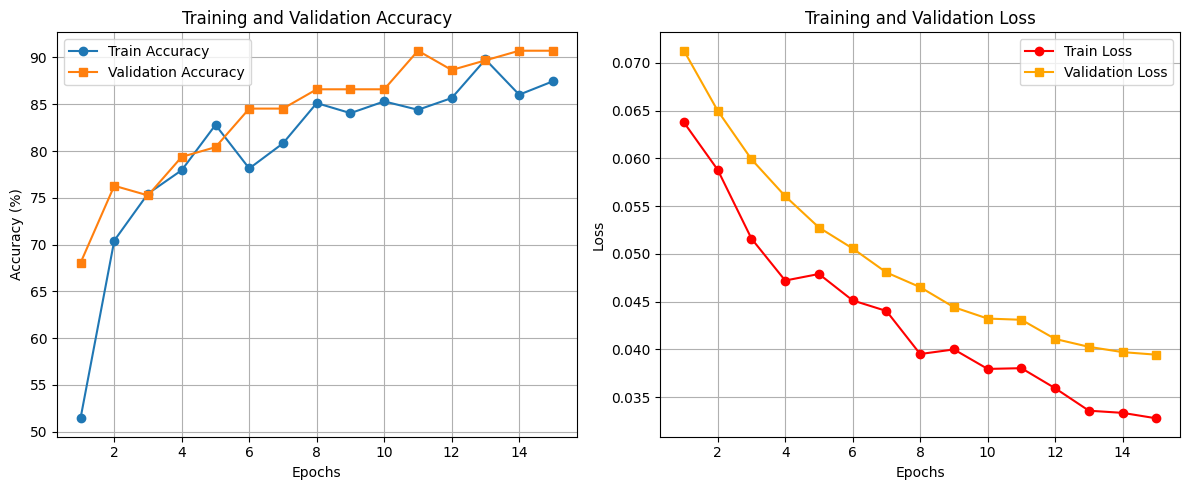

In [ ]:
# ======================================================
# 4. TAHAP 3: ARSITEKTUR MULTIMODAL SWIN (TRANSFER LEARNING)
# ======================================================
class QualityAwareSwin(nn.Module):
    def __init__(self, model_name='swin_base_patch4_window7_224', pretrained=True):
        super(QualityAwareSwin, self).__init__()
        self.swin = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        swin_out_features = self.swin.num_features

        self.quality_mlp = nn.Sequential(
            nn.Linear(1, 16),
            nn.GELU(),
            nn.Linear(16, 16),
            nn.GELU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(swin_out_features + 16, 512),
            nn.GELU(),
            nn.Dropout(0.5), # Naikkan dropout untuk mencegah model menghafal
            nn.Linear(512, 2)
        )

    def forward(self, image, quality_score):
        v_feat = self.swin(image)
        if quality_score.dim() == 1: quality_score = quality_score.unsqueeze(1)
        q_feat = self.quality_mlp(quality_score)
        fused = torch.cat((v_feat, q_feat), dim=1)
        return self.classifier(fused)

model = QualityAwareSwin().to(device)

# --- STRATEGI ANTI-OVERFITTING: FREEZE SWIN BACKBONE ---
print("--- Mengunci (Freeze) Layer Swin Transformer ---")
for param in model.swin.parameters():
    param.requires_grad = False

# Pastikan MLP dan Classifier tetap bisa belajar
for param in model.quality_mlp.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

# ======================================================
# 5. TAHAP 4: TRAINING DENGAN FOCAL LOSS & EVALUASI
# ======================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=[0.75, 0.25], gamma=2.0): # Parameter diperhalus
        super(FocalLoss, self).__init__()
        self.alpha = torch.tensor(alpha, dtype=torch.float32).to(device)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha[targets] * ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

epochs = 15 # Kita jalankan 15 epoch agar pola grafiknya terlihat
criterion = FocalLoss()

# LR diturunkan 10x lipat (1e-5), Weight Decay dinaikkan (0.05)
# Kita hanya meng-optimasi parameter yang requires_grad=True
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# --- LIST UNTUK MENYIMPAN HISTORY TRAINING ---
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print(f"\n--- Memulai Training selama {epochs} Epochs ---")
for epoch in range(epochs):
    # --- FASE TRAINING ---
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0

    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for batch in pbar_train:
        img, qty, lbl = batch['image'].to(device), batch['quality'].to(device), batch['label'].to(device)

        optimizer.zero_grad()
        out = model(img, qty)
        loss = criterion(out, lbl)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, pred = torch.max(out, 1)
        total_train += lbl.size(0)
        correct_train += (pred == lbl).sum().item()
        pbar_train.set_postfix(loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train * 100

    # --- FASE VALIDATION ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            img, qty, lbl = batch['image'].to(device), batch['quality'].to(device), batch['label'].to(device)
            out = model(img, qty)
            loss = criterion(out, lbl)

            running_val_loss += loss.item()
            _, pred = torch.max(out, 1)
            total_val += lbl.size(0)
            correct_val += (pred == lbl).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = correct_val / total_val * 100

    # Simpan ke history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1} Hasil -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

    # Update scheduler berdasarkan Val Loss
    scheduler.step(epoch_val_loss)

# ======================================================
# VISUALISASI LEARNING CURVES
# ======================================================
plt.figure(figsize=(12, 5))

# Grafik 1: Akurasi
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), history['val_acc'], label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Grafik 2: Loss
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), history['train_loss'], label='Train Loss', marker='o', color='red')
plt.plot(range(1, epochs+1), history['val_loss'], label='Validation Loss', marker='s', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Evaluasi pada Validation Set ---
AUROC Score: 0.9296 (Semakin mendekati 1.0 semakin baik model membedakan kelas)
⭐ Ambang Batas (Threshold) Paling Optimal: 0.4747
🏆 F1-Score Macro Maksimal: 0.9052

Classification Report (Dengan Optimal Threshold):
              precision    recall  f1-score   support

        GON-       0.87      0.87      0.87        31
        GON+       0.94      0.94      0.94        66

    accuracy                           0.92        97
   macro avg       0.91      0.91      0.91        97
weighted avg       0.92      0.92      0.92        97



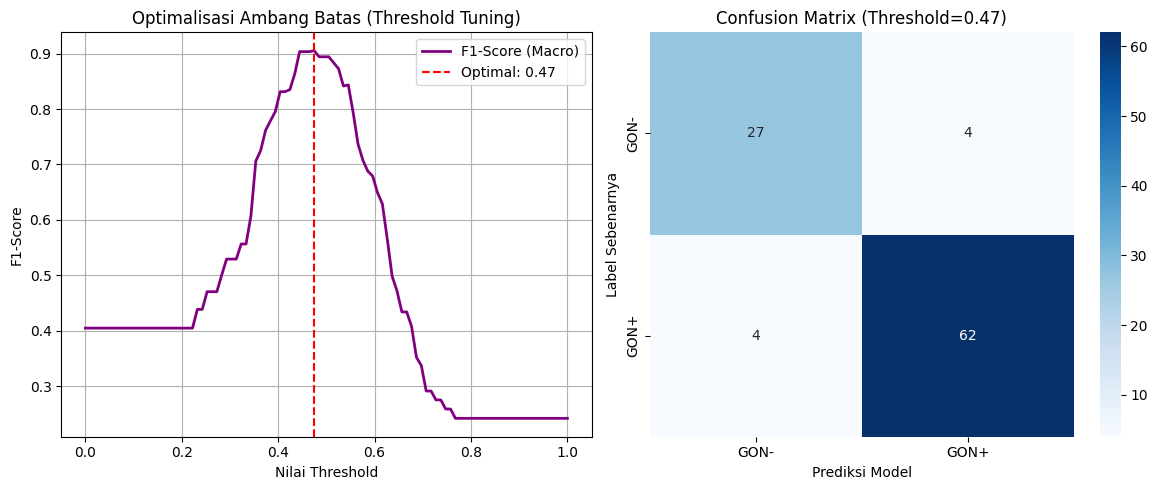

In [ ]:
# ======================================================
# 6. TAHAP 5: EVALUASI & THRESHOLD OPTIMIZATION (F1-MAX)
# ======================================================
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Evaluasi pada Validation Set ---")
model.eval()
all_lbl, all_prob = [], []

with torch.no_grad():
    for batch in val_loader:
        img, qty, lbl = batch['image'].to(device), batch['quality'].to(device), batch['label'].to(device)
        out = model(img, qty)
        prob = torch.softmax(out, dim=1)[:, 1] # Ambil probabilitas untuk GON+
        all_lbl.extend(lbl.cpu().numpy())
        all_prob.extend(prob.cpu().numpy())

all_lbl = np.array(all_lbl)
all_prob = np.array(all_prob)

# 1. Hitung AUROC Mentah
auroc = roc_auc_score(all_lbl, all_prob)
print(f"AUROC Score: {auroc:.4f} (Semakin mendekati 1.0 semakin baik model membedakan kelas)")

# 2. Simulasi Pencarian Threshold berdasarkan F1-Score
thresholds = np.linspace(0.0, 1.0, 100) # Buat 100 titik uji dari 0 sampai 1
f1_scores = []

for t in thresholds:
    preds = (all_prob >= t).astype(int)
    # Rata-rata harmonik (macro) agar adil untuk GON+ dan GON-
    f1 = f1_score(all_lbl, preds, average='macro')
    f1_scores.append(f1)

# Ambil threshold yang menghasilkan F1-Score tertinggi
optimal_idx = np.argmax(f1_scores)
opt_thresh = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"⭐ Ambang Batas (Threshold) Paling Optimal: {opt_thresh:.4f}")
print(f"🏆 F1-Score Macro Maksimal: {best_f1:.4f}")

# 3. Terapkan Threshold Tersebut
opt_preds = (all_prob >= opt_thresh).astype(int)

# 4. Tampilkan Classification Report
print("\nClassification Report (Dengan Optimal Threshold):")
print(classification_report(all_lbl, opt_preds, target_names=['GON-', 'GON+']))

# 5. Visualisasi Analisis Threshold & Confusion Matrix
plt.figure(figsize=(12, 5))

# Plot Kurva F1 vs Threshold
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, label='F1-Score (Macro)', color='purple', linewidth=2)
plt.axvline(x=opt_thresh, color='red', linestyle='--', label=f'Optimal: {opt_thresh:.2f}')
plt.title('Optimalisasi Ambang Batas (Threshold Tuning)')
plt.xlabel('Nilai Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

# Plot Confusion Matrix
cm = confusion_matrix(all_lbl, opt_preds)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['GON-', 'GON+'], yticklabels=['GON-', 'GON+'])
plt.title(f'Confusion Matrix (Threshold={opt_thresh:.2f})')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')

plt.tight_layout()
plt.show()


--- Visualisasi The Insights pada Test Set ---


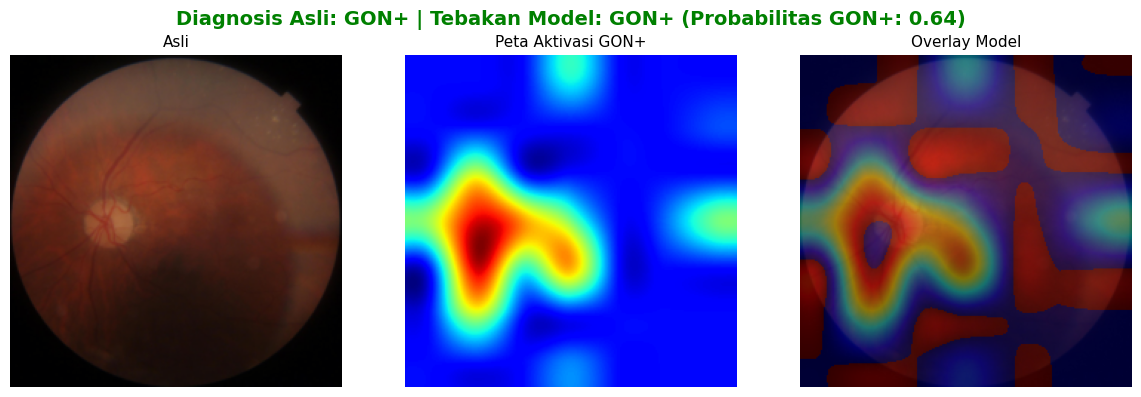

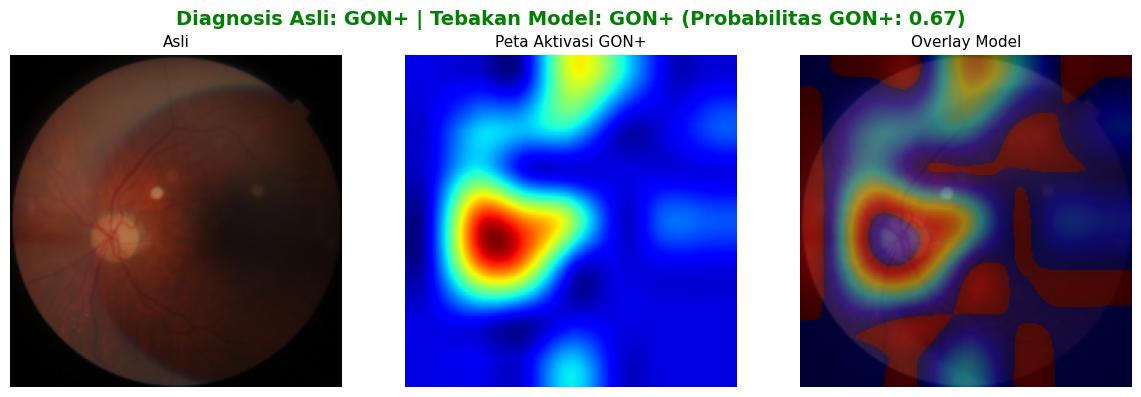

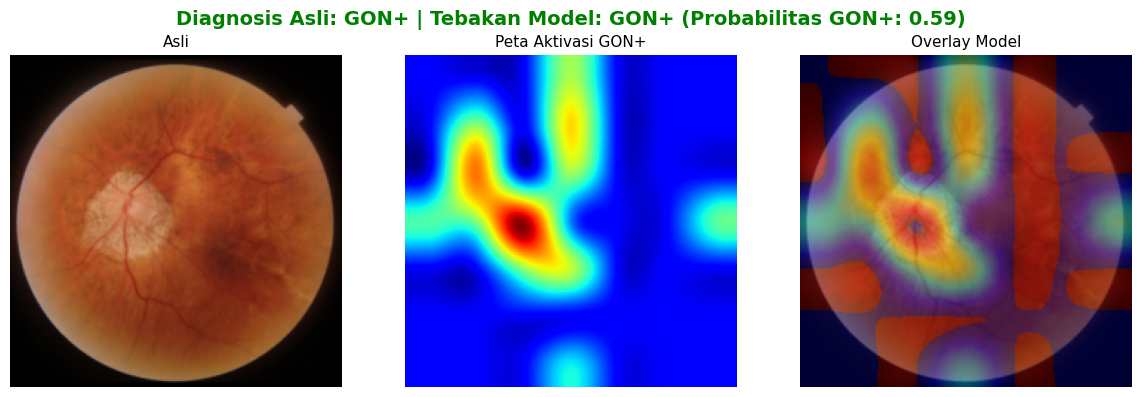

In [ ]:
# ======================================================
# 7. TAHAP 6: VISUALISASI KLINIS UNTUK THE INSIGHTS
# ======================================================

# ------------------------------------------------------
# A. Definisi Mesin Grad-CAM (Satu baris ditambahkan untuk mengatasi error NoneType)
# ------------------------------------------------------
class MathGradCAM:
    def __init__(self, model, target_module):
        self.model = model
        self.feature_map, self.gradient = None, None
        target_module.register_forward_hook(self.save_feat)
        target_module.register_full_backward_hook(self.save_grad)

    def save_feat(self, mod, inp, out): self.feature_map = out.detach()
    def save_grad(self, mod, g_in, g_out): self.gradient = g_out[0].detach()

    def generate(self, img_tsr, qty_tsr, tgt_cls):
        self.model.eval()
        self.model.zero_grad()

        # BARIS SAKTI: Memaksa PyTorch mengaktifkan gradien meskipun backbone Swin di-freeze
        img_tsr.requires_grad_()

        out = self.model(img_tsr, qty_tsr)
        out[0, tgt_cls].backward(retain_graph=True)

        feat, grad = self.feature_map[0], self.gradient[0]

        if feat.dim() == 2: # Fix format output Swin Transformer
            size = int(np.sqrt(feat.shape[0]))
            feat = feat.view(size, size, -1)
            grad = grad.view(size, size, -1)

        alpha = torch.mean(grad, dim=(0, 1))
        cam = torch.zeros(feat.shape[:2], dtype=torch.float32, device=feat.device)
        for i, w in enumerate(alpha): cam += w * feat[:, :, i]

        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam.cpu().detach().numpy()

# ------------------------------------------------------
# B. Definisi Fungsi Pelukis Peta Panas
# ------------------------------------------------------
def show_heatmap(dataset, idx, optimal_threshold=0.5):
    sample = dataset[idx]
    img = sample['image'].unsqueeze(0).to(device)
    qty = sample['quality'].unsqueeze(0).to(device)
    lbl = sample['label'].item()

    # 1. Melakukan Prediksi
    model.eval()
    with torch.no_grad():
        out = model(img, qty)
        prob_gon_plus = torch.softmax(out, dim=1)[0, 1].item()
        pred_label = 1 if prob_gon_plus >= optimal_threshold else 0

    # 2. Ekstraksi Fitur (Mencari tanda GON+ / kelas 1)
    target_class = 1
    grad_cam = MathGradCAM(model, model.swin.layers[-1].blocks[-1])
    cam_raw = grad_cam.generate(img, qty, tgt_cls=target_class)

    # 3. Denormalisasi Gambar Asli (Mengembalikan warna)
    cam_rsz = cv2.resize(cam_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_disp = np.clip(std * img.cpu().squeeze().permute(1, 2, 0).detach().numpy() + mean, 0, 1)

    # 4. Membuat Overlay
    hm = np.float32(cv2.applyColorMap(np.uint8(255 * cam_rsz), cv2.COLORMAP_JET))[..., ::-1] / 255
    overlay = np.clip(hm * 0.4 + img_disp * 0.6, 0, 1)

    # 5. Menampilkan Grafik
    plt.figure(figsize=(12, 4))
    for i, (pic, tit) in enumerate(zip([img_disp, cam_rsz, overlay], ["Asli", "Peta Aktivasi GON+", "Overlay Model"])):
        plt.subplot(1, 3, i+1)
        plt.imshow(pic, cmap='jet' if i==1 else None)
        plt.title(tit, fontsize=11)
        plt.axis('off')

    # 6. Menentukan Warna Teks Judul (Hijau=Benar, Merah=Salah)
    str_asli = 'GON+' if lbl==1 else 'GON-'
    str_pred = 'GON+' if pred_label==1 else 'GON-'
    color = 'green' if str_asli == str_pred else 'red'

    plt.suptitle(f"Diagnosis Asli: {str_asli} | Tebakan Model: {str_pred} (Probabilitas GON+: {prob_gon_plus:.2f})",
                 fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------
# C. Eksekusi Akhir pada Test Set
# ------------------------------------------------------
print("\n--- Visualisasi The Insights pada Test Set ---")

# WAJIB: Membungkus df_test menjadi format Dataset agar bisa diproses PyTorch
test_ds = HYGDDataset(df_test, IMAGE_DIR, cols, is_train=False)

# Menggunakan Threshold yang didapat dari Tahap 5 secara otomatis
OPT_THRESH = opt_thresh

# Menampilkan Laporan untuk 3 Pasien Pertama di Test Set
for i in range(3):
    show_heatmap(test_ds, idx=i, optimal_threshold=OPT_THRESH)